In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [ ]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\QOO660 herox.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41145 entries, 0 to 41144
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  41145 non-null  str  
 1   Message  41145 non-null  str  
 2   Status   41145 non-null  str  
dtypes: str(3)
memory usage: 964.5 KB


In [ ]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [ ]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-09-23 14:25:36.746 Last fuel report fs02:  2026-09-23 14:22:52.591


In [ ]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 18344 entries, 0 to 18343
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18344 non-null  int64
 1   date      18344 non-null  str  
 2   raw data  18344 non-null  str  
dtypes: int64(1), str(2)
memory usage: 430.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 7529 entries, 0 to 7528
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     7529 non-null   int64
 1   date      7529 non-null   str  
 2   raw data  7529 non-null   str  
dtypes: int64(1), str(2)
memory usage: 176.6 KB


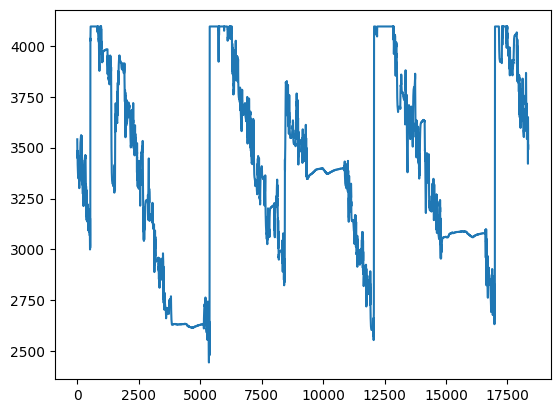

In [ ]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

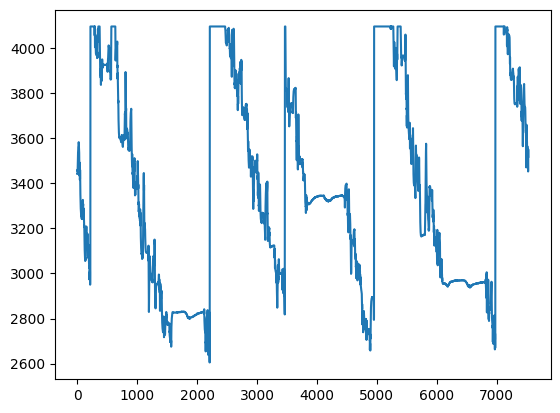

In [ ]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [ ]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

In [ ]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 18344 entries, 0 to 18343
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18344 non-null  int64
 1   date      18344 non-null  str  
 2   raw data  18344 non-null  str  
dtypes: int64(1), str(2)
memory usage: 573.2 KB


In [ ]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.0973
b1=-29.968
m2=0.0973
b2=-29.968

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
Index: 18344 entries, 0 to 18343
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18344 non-null  int64
 1   date      18344 non-null  str  
 2   raw data  18344 non-null  str  
dtypes: int64(1), str(2)
memory usage: 573.2 KB


In [ ]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260907180000
date2=260907181800

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
raising 73.89871961096969 73.17900931259265 0.7197102983770378
raising 74.90117324085197 73.89871961096969 1.7221639282593202
droping 71.66247689815533 74.90117324085197 -1.5165324144373216
raising 73.51316052255342 71.66247689815533 0.3341512099607655
raising 74.0529432463362 73.51316052255342 0.8739339337435439
raising 74.64413384857448 74.0529432463362 1.465124535981829
raising 75.74940323536778 74.64413384857448 2.570393922775125
raising 87.80455073318306 75.74940323536778 14.625541420590409
raising 113.17433875097348 87.80455073318306 39.99532943838082
Level change tank 1:  39.99532943838082
Level change tank 1 + Level change tank 2: 
droping 74.87546930162424 74.97828505853523 39.89251368146982
raising 75.82651505305103 74.87546930162424 40.84355943289661
raising 113.17433875097348 75.82651505305103 78.19138313081906
Level change toal:  78.19138313081906


Adding the validation to delete the value that beongs to ragistger i+1, in this case to delete 38.36 that belongs to 260821130825 4046.

In [ ]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260907180000
date2=260907181800
level=0

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 73.89871961096969 73.17900931259265 0.7197102983770378 0.7197102983770378
raising 74.90117324085197 73.89871961096969 1.7221639282593202 1.0024536298822824
droping 71.66247689815533 74.90117324085197 -1.5165324144373216 -3.2386963426966418
raising 73.51316052255342 71.66247689815533 0.3341512099607655 1.850683624398087
raising 74.0529432463362 73.51316052255342 0.8739339337435439 0.5397827237827784
raising 74.64413384857448 74.0529432463362 1.465124535981829 0.5911906022382851
raising 75.74940323536778 74.64413384857448 2.570393922775125 1.105269386793296
raising 87.80455073318306 75.74940323536778 14.625541420590409 12.055147497815284
raising 113.17433875097348 87.80455073318306 39.99532943838082 25.369788017790412
Level change tank 1:  39.99532943838082
Level change tank 1 + Level change tank 2: 
droping 74.87546930162424 74.97828505853523 39.89251368146982 -0.10281575691099931
raisin

In [ ]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260907180000
date2=260907181800
level=0

delta_aux=[]
x_after=[]
x_=[]

df_report=pd.DataFrame()

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):            
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

df_report['x_']=x_
df_report['x_after']=x_after
df_report['delta']=delta_aux

df_report

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 73.89871961096969 73.17900931259265 0.7197102983770378 0.7197102983770378
raising 74.90117324085197 73.89871961096969 1.7221639282593202 1.0024536298822824
droping 71.66247689815533 74.90117324085197 -1.5165324144373216 -3.2386963426966418
raising 73.51316052255342 71.66247689815533 0.3341512099607655 1.850683624398087
raising 74.0529432463362 73.51316052255342 0.8739339337435439 0.5397827237827784
raising 74.64413384857448 74.0529432463362 1.465124535981829 0.5911906022382851
raising 75.74940323536778 74.64413384857448 2.570393922775125 1.105269386793296
raising 87.80455073318306 75.74940323536778 14.625541420590409 12.055147497815284
raising 113.17433875097348 87.80455073318306 39.99532943838082 25.369788017790412
Level change tank 1:  39.99532943838082
Level change tank 1 + Level change tank 2: 
droping 74.87546930162424 74.97828505853523 39.89251368146982 -0.10281575691099931
raisin

,x_,x_after,delta
0,73.179009,73.898720,0.719710
1,73.898720,74.901173,1.002454
2,74.901173,71.662477,-3.238696
3,71.662477,73.513161,1.850684
4,73.513161,74.052943,0.539783
5,74.052943,74.644134,0.591191
6,74.644134,75.749403,1.105269
7,75.749403,87.804551,12.055147
8,87.804551,113.174339,25.369788
9,100.193849,100.605112,-0.102816
